In [1]:


import jax 
import jax.numpy as jnp
import jax.random as jrandom


import haiku as hk
import optax

import matplotlib.pyplot as plt

from probjax.nn.transformers import Transformer
from probjax.nn.tokenizer import scalarize, ScalarTokenizer
from probjax.nn.helpers import GaussianFourierEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss

from probjax.distributions.sde import VPSDE, BaseSDE
from probjax.distributions import Normal, Independent
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions.discrete import Empirical

from probjax.utils.sdeint import sdeint
from probjax.utils.odeint import _odeint
from probjax.utils.graph import min_faithfull_mask

from functools import partial



In [2]:
cpu = jax.devices("cpu")[0]
jax.devices()

[cuda(id=0)]

In [3]:
ts = jnp.linspace(0, 3, 100)


V0 = -65.0  # Initial membrane voltage (mV)


def I_inj_fn(t, t_val, Vt_val):
    index = jnp.searchsorted(t_val, t, side='right') - 1
    return jax.lax.cond(index < 0, lambda _: 0.0, lambda _: Vt_val[index], None)

def efun(x):
    return jnp.where(x < 1e-4, 1-x /2, x/(jnp.exp(x) - 1.0))

def alpha_m_fn(V):
    return 0.32 * efun(-0.25*(V - V0 - 13.0)) / 0.25

def beta_m_fn(V):
    return 0.28 * efun(0.2*(V - V0 - 40.0)) / 0.2

def alpha_h_fn(V):
    return 0.128 * jnp.exp(-(V - V0 - 17.0) / 18.0)

def beta_h_fn(V):
    return 4.0 / (1.0 + jnp.exp(-(V - V0 - 40.0) / 5.0))

def alpha_n_fn(V):
    return 0.032 * efun(-0.2*(V - V0 - 15.0)) / 0.2

def beta_n_fn(V):
    return 0.5 * jnp.exp(-(V - V0 - 10.0) / 40.0)

def hodgkin_huxley(t, state, Cm, g_Na, g_K, g_L, E_Na, E_K, E_L, t_val,Vt_val, voltage_based_energy=False):
    V, m, h, n, H = state

    # Membrane capacitance (uF/cm^2)
    # Sodium conductance (mS/cm^2)
    # Potassium conductance (mS/cm^2)
    # Leak conductance (mS/cm^2)
    # Sodium reversal potential (mV)
    # Potassium reversal potential (mV)
    # Leak reversal potential (mV)

    # Alpha and beta functions for m, h, and n
    alpha_n = alpha_n_fn(V)
    beta_n = beta_n_fn(V)
    alpha_m = alpha_m_fn(V)
    beta_m = beta_m_fn(V)
    alpha_h = alpha_h_fn(V)
    beta_h = beta_h_fn(V)
    
    i_Na = g_Na * m**3 * h * (V - E_Na)
    i_K = g_K * n**4 * (V - E_K)
    i_L = g_L * (V - E_L)
    # Hodgkin-Huxley ODEs
    dV = (I_inj_fn(t, t_val, Vt_val) - i_Na - i_K - i_L) / Cm
    dm = alpha_m * (1.0 - m) - beta_m * m
    dh = alpha_h * (1.0 - h) - beta_h * h
    dn = alpha_n * (1.0 - n) - beta_n * n
    if voltage_based_energy:
        # Voltage-based energy 
        dH = (V*I_inj_fn(t, t_val, Vt_val) - i_Na * (V - E_Na) - i_K * (V - E_K) - i_L * (V - E_L)) / 10**6 # in mJ
    else:
        # Natiumm-based energy - Charge based energy
        dH = i_Na  # in mJ

    return dV, dm, dh, dn, dH

t_min = 0.0
t_max = 200.

params = (1.0, 100.0, 40.0, 0.1, 53.0, -107.0, -70)
noise_fact = 0.05
t_val = jnp.array([50., 150])
Vt_val = jnp.array([4., 0])

diffusion_fn = lambda t, state, *args: jnp.array([noise_fact, 0., 0., 0., 0.])

ts_dense = jnp.linspace(t_min, t_max, 5000)
dt = ts_dense[1] - ts_dense[0]
m0 = alpha_n_fn(V0) / (alpha_n_fn(V0) + beta_n_fn(V0))
h0 = alpha_h_fn(V0) / (alpha_h_fn(V0) + beta_h_fn(V0))
n0 = alpha_m_fn(V0) / (alpha_m_fn(V0) + beta_m_fn(V0))
H0 = jnp.zeros_like(V0)

vals = sdeint(jax.random.PRNGKey(0),hodgkin_huxley, diffusion_fn, (V0, m0, h0, n0, H0), ts_dense, *params, t_val, Vt_val, noise_type="diagonal")

In [4]:
@jax.vmap
def sim(key):
    return sdeint(key,hodgkin_huxley, diffusion_fn, (V0, m0, h0, n0, H0), ts_dense, *params, t_val, Vt_val, noise_type="diagonal")[:, 0]

In [5]:
VS = sim(jax.random.split(jax.random.PRNGKey(0), 500))

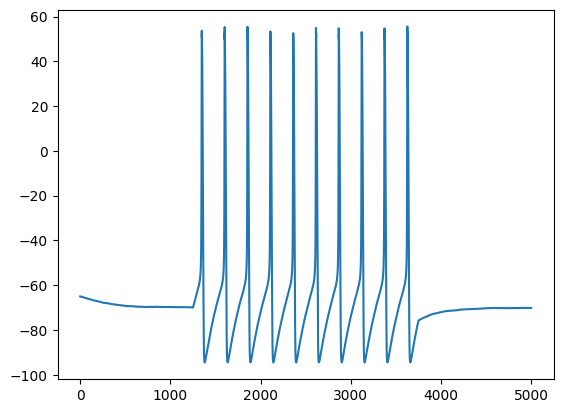

In [6]:
plt.plot(VS[3])

In [7]:
from scoresbibm.src.tasks import HHTask
from scoresbibm.src.tasks.hhtask import compute_summary_statistics
from scoresbibm.src.methods.neural_nets import structured_transformer_model
from scoresbibm.src.methods.score_transformer import get_z_score_fn, init_sde_related

In [8]:
task = HHTask()
node_id = task.get_node_id()
dataset = task.get_data(1000, rng = jax.random.PRNGKey(0))

In [9]:
data = jnp.concatenate([dataset["theta"], dataset["x"]], axis=-1)[..., None]
data = jnp.split(data, data.shape[-2], axis=-2)
data = jax.tree_map(lambda x: x.squeeze(-2), data)
data_names = ["theta0", "theta1", "theta2","theta3", "theta4", "theta5","theta6", "x0", "x1", "x2","x3", "x4", "x5","x6", "x7"]
data = dict(zip(data_names, data))


In [10]:
def int2bit(x, dtype = jnp.uint8):
    return jnp.unpackbits(x.astype(dtype), axis=-1).reshape(x.shape[:-1] + (-1,)).astype(jnp.float32)

def bit2int(x, dtype = jnp.uint8):
    return jnp.packbits(x.astype(dtype), axis=-1).reshape(x.shape[:-1]).astype(jnp.float32)
    

In [11]:
data["x0"]= int2bit(data["x0"])

In [12]:
jax.tree_map(lambda x: x.shape, data)

{'theta0': (1000, 1),
 'theta1': (1000, 1),
 'theta2': (1000, 1),
 'theta3': (1000, 1),
 'theta4': (1000, 1),
 'theta5': (1000, 1),
 'theta6': (1000, 1),
 'x0': (1000, 8),
 'x1': (1000, 1),
 'x2': (1000, 1),
 'x3': (1000, 1),
 'x4': (1000, 1),
 'x5': (1000, 1),
 'x6': (1000, 1),
 'x7': (1000, 1)}

In [13]:
sde_related = jax.tree_map(init_sde_related, data)

In [14]:
sde_related0 = sde_related["theta0"]
sde, T_min, T_max, weight_fn, output_scale_fn = sde_related0

In [15]:
data_name_to_id = {name: i for i, name in enumerate(data_names)}

In [16]:
init_fn, model_fn = structured_transformer_model(len(node_id), data_name_to_id,output_scale_fn=output_scale_fn)

In [17]:
params = init_fn(
        jax.random.PRNGKey(0),
        jnp.ones((10,)),
        jax.tree_map(lambda x: x[:10], data),   
        jnp.zeros_like(node_id),
    )

In [19]:
#with jax.disable_jit():
out = model_fn(
        params,
        jnp.ones((10,)),
        jax.tree_map(lambda x: x[:10], data),   
        jnp.zeros_like(node_id),
    )

In [21]:
def edge_mask_fn(node_id, condition_mask):
    return None 

def condition_mask_fn(key, batch_size ,theta_dim, x_dim):
    return jnp.zeros((batch_size, theta_dim + x_dim))

theta_dim = 7
x_dim = 8

In [22]:
from probjax.utils.jaxutils import ravel_args

In [23]:
def flatten_data(data):
    return jnp.concatenate([d for d in data], axis=-1)[..., None]

def unflatten_data(data):
    return jnp.split(data, [theta_dim, theta_dim + x_dim], axis=-1)

def model_fn_wrapper(params, t, data, node_id, condition_mask, edge_mask):
    data = unflatten_data(data)
    return model_fn(params, t, data, node_id, condition_mask, edge_mask)

In [41]:
@jax.jit
def loss_fn(params, key, data, meta_data):
    key_times, key_loss, key_condition = jax.random.split(key, 3)
    batch_size = list(data.values())[0].shape[0]  
    times = jax.random.uniform(
        key_times, (batch_size,), minval=T_min, maxval=T_max
    )

    # Structured conditioning
    condition_mask = condition_mask_fn(
        key_condition, batch_size, theta_dim, x_dim
    )
    if meta_data is None:
        edge_mask = edge_mask_fn(node_id, condition_mask)
    else:
        edge_mask = jax.vmap(edge_mask_fn, in_axes=(None, None, 0))(node_id, condition_mask, meta_data)
        

    data_t = {}
    score_target = []
    loss_mask = []
    for i,(k, x) in enumerate(data.items()):
        key, key_eps = jax.random.split(key_loss)
        eps = jax.random.normal(key_eps, shape=x.shape)
        mean_t = sde.marginal_mean(times, x)
        std_t = sde.marginal_stddev(times, x)
        xs_t = mean_t + std_t * eps
        xs_t = jnp.where(condition_mask[:, i:i+1], x, xs_t)
        data_t[k] = xs_t
        score_target.append(-eps / std_t)
        loss_mask.append(jnp.repeat(condition_mask[:, i:i+1], x.shape[-1], axis=-1))
        
    score_pred = model_fn(params, times, data_t, condition_mask, edge_mask)
    score_target = jnp.concatenate(score_target, axis=-1)
    loss_mask = jnp.concatenate(loss_mask, axis=-1)


    loss = (score_pred - score_target) ** 2
    loss = jnp.where(loss_mask, 0.0,loss)
    loss = weight_fn(times) * jnp.sum(loss, axis=-1, keepdims=True)
    loss = jnp.mean(loss)

    return loss

@partial(jax.pmap, axis_name="num_devices")
def update(params, opt_state, key, data, node_id, meta_data):
    loss, grads = jax.value_and_grad(loss_fn)(params, key, data, node_id, meta_data)

    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")

    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [44]:
loss_fn(params, jax.random.PRNGKey(0), data, None)

Array(23.013, dtype=float32)